In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/wine.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


(None,
    Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
 0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
 1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
 2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
 3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
 4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   
 
    Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
 0           0.28             2.29   5.64  1.04      3.92     1065  
 1           0.26             1.28   4.38  1.05      3.40     1050  
 2           0.30             2.81   5.68  1.03      3.17     1185  
 3           0.24             2.18   7.80  0.86      3.45     1480  
 4           0.39             1.82   4.32  1.04      2.93      735  )

**EDA - Step 1: Basic Exploration**

1.  Dataset Shape:178 rows and 14 columns.
2.  No Missing Values: All columns have complete data.
3.  Column Types:
   *  Type is an integer (likely representing wine categories)
   *  Other columns are numerical (float or int).
4. First Few Rows:
   *  Alcohol, Malic, Ash, etc., seem to be chemical properties of wine.
   *  Proline has high values compared to others, indicating potential scale differences.


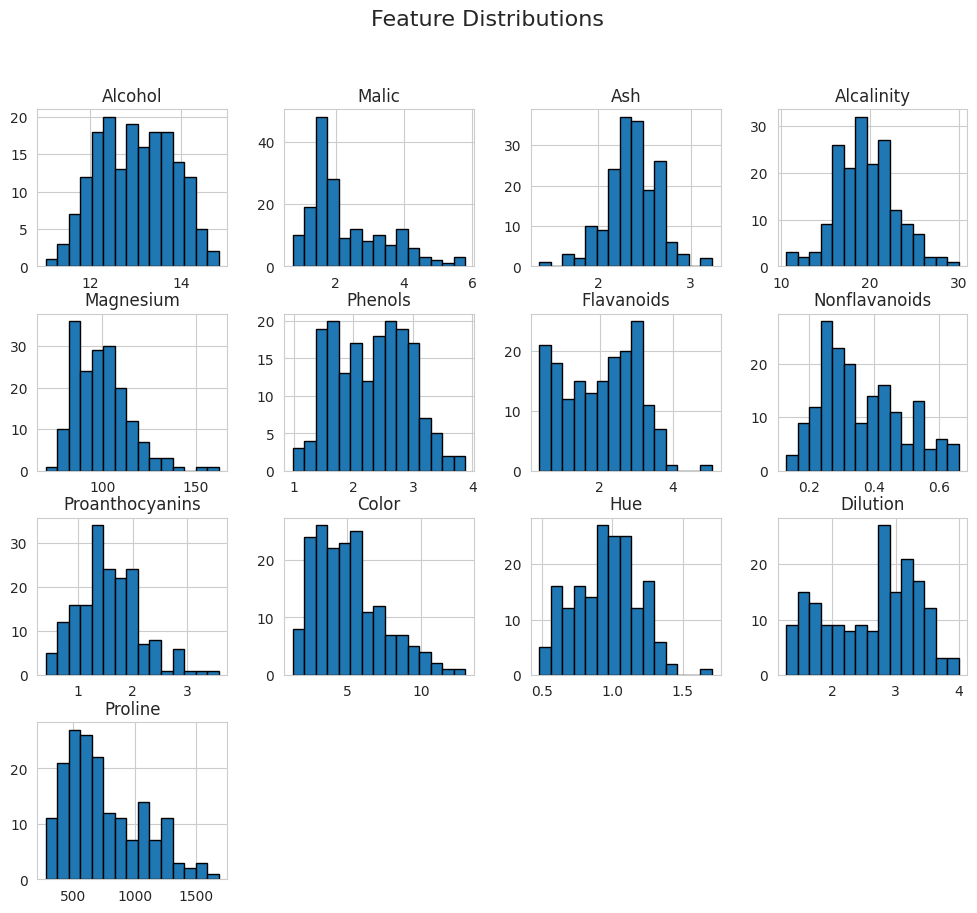

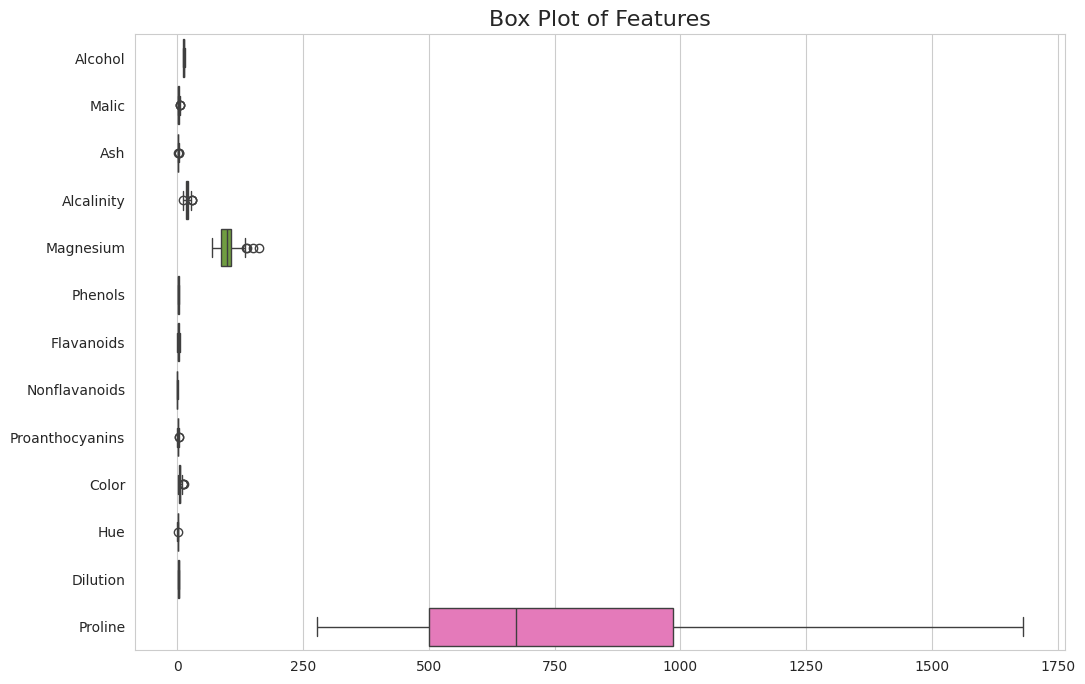

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Plot histograms for all numerical columns
df.drop(columns=["Type"]).hist(figsize=(12, 10), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Box plots to check for outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.drop(columns=["Type"]), orient="h")
plt.title("Box Plot of Features", fontsize=16)
plt.show()



**EDA - Step 2: Feature Distribution Insights**

1. Histograms:
     * Some features (e.g., Proline, Alcohol, Color) are right-skewed.
     * Others (e.g., Flavanoids, Phenols) show relatively normal distributions.
2. Box Plots:
     * Several features have outliers, particularly Proline, Color, and Malic.


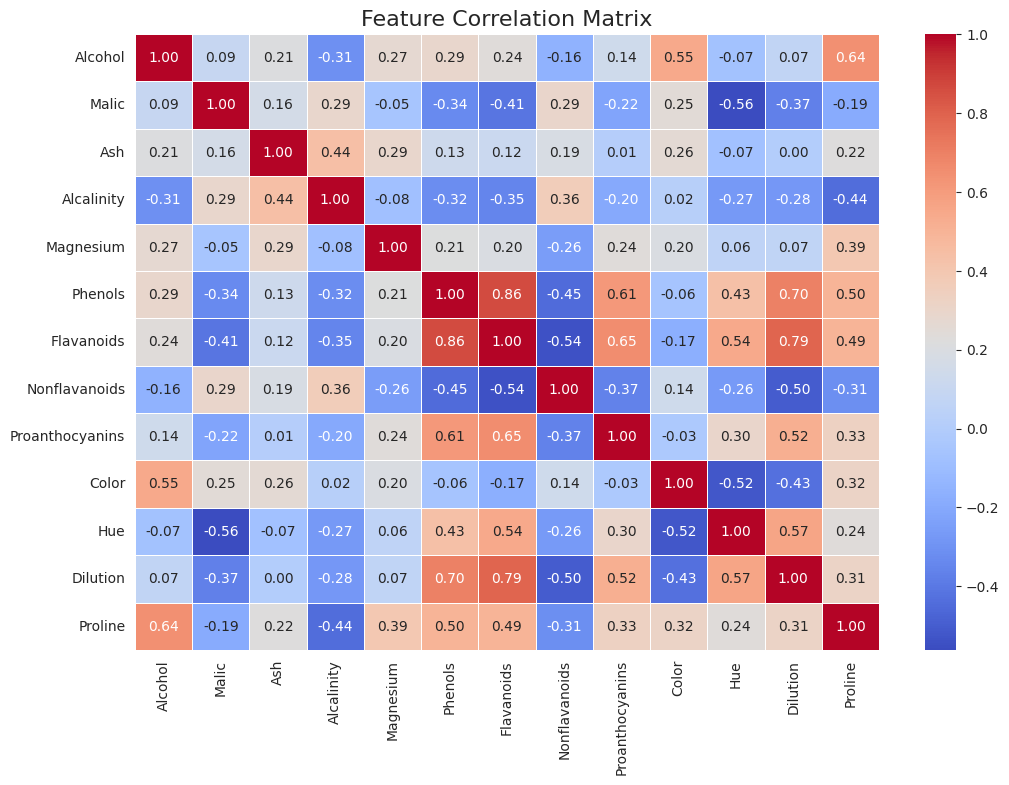

In [ ]:
 # Compute correlation matrix
corr_matrix = df.drop(columns=["Type"]).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()


**EDA - Step 3: Correlation Analysis Insights**

1. Strong Positive Correlations:
   * Flavanoids and Phenols (0.86)—both related to wine's chemical composition.
   * Dilution and Hue (0.79)—potentially related to wine color intensity.
2. Strong Negative Correlations:
   * Flavanoids and Nonflavanoids (−0.72)—likely due to compositional differences.
3. Key Takeaway:
   * Some features are highly correlated, meaning PCA may be beneficial in reducing redundancy.

**Task 2 - Dimensionality Reduction with PCA**

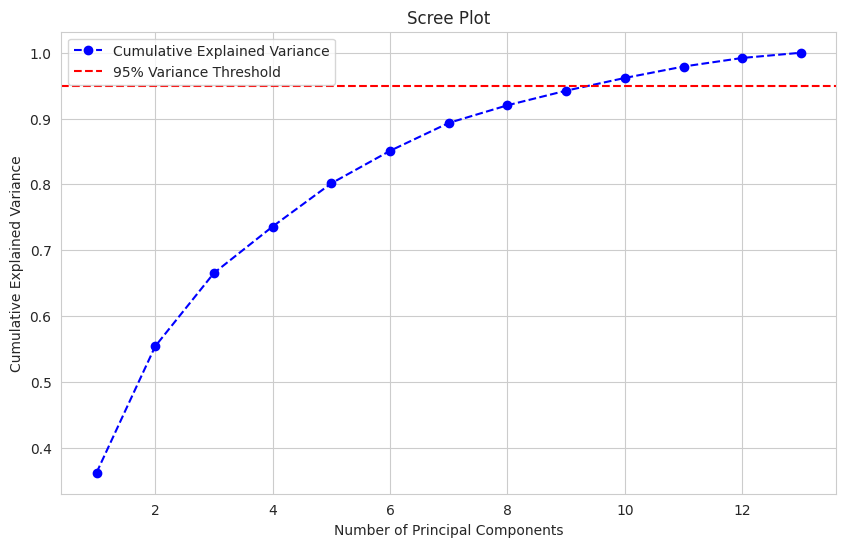

10

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Standardize the features (excluding 'Type' column)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=["Type"]))

# Apply PCA
pca = PCA()
pca.fit(df_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Scree plot for optimal component selection
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b', label='Cumulative Explained Variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance Threshold")
plt.legend()
plt.show()

# Determine the optimal number of components (95% variance threshold)
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1
optimal_components


 **PCA Step 1 and 2: standardization and component selection**

1. Standardization: All features were scaled to have a mean of 0 and a standard deviation of 1.
2. Scree Plot Analysis:
   * The first few components explain a significant portion of the variance.
   * Optimal number of components: 10, as they collectively explain 95% of the variance.


In [ ]:
# Apply PCA with the optimal number of components
pca_optimal = PCA(n_components=optimal_components)
df_pca = pca_optimal.fit_transform(df_scaled)

# Convert to DataFrame
df_pca = pd.DataFrame(df_pca, columns=[f"PC{i+1}" for i in range(optimal_components)])
df_pca.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366


 **step** **3 :** **dataset** **transformation**

* The original dataset is now represented using 10 principal components.
* Each principal component captures significant variance from the original features.

**Task 3 - Clustering on Original Data**

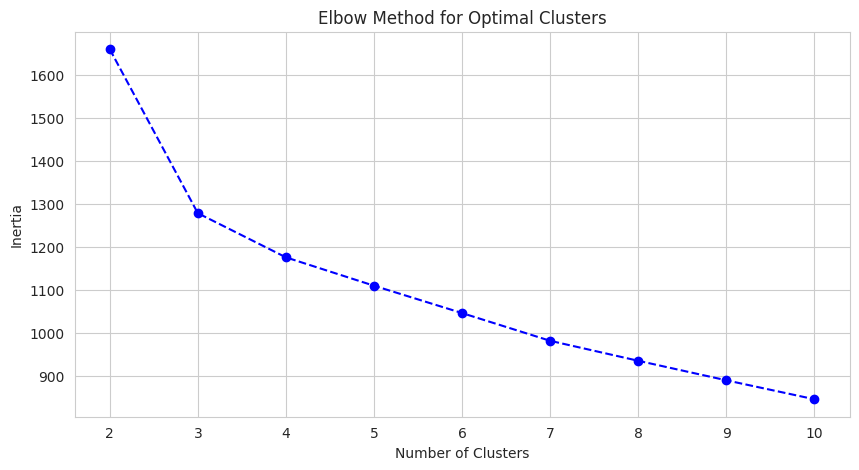

3

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine the optimal number of clusters using the Elbow method
inertia = []
silhouette_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot Elbow method
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# Determine the optimal number of clusters based on silhouette score
optimal_k = cluster_range[np.argmax(silhouette_scores)]
optimal_k


**Clustering on Original Data - Step 1: Determining Optimal Clusters**
1. Elbow Method:  
      The curve starts to flatten at k = 3, suggesting it as a good choice.
2. Silhouette Score Analysis:
     The highest score is also at k = 3, confirming 3 clusters as optimal.


In [ ]:
# Apply K-Means with optimal k
kmeans_original = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster_Original"] = kmeans_original.fit_predict(df_scaled)

# Compute clustering performance metrics
silhouette_original = silhouette_score(df_scaled, df["Cluster_Original"])
davies_bouldin_original = davies_bouldin_score(df_scaled, df["Cluster_Original"])

silhouette_original, davies_bouldin_original


(0.2848589191898987, 1.3891879777181648)

**Clustering on Original Data - Step 2: Results**

 * Silhouette Score:
0.28 (moderate clustering quality).

 * Davies-Bouldin Index:
1.39 (lower values indicate better clustering)

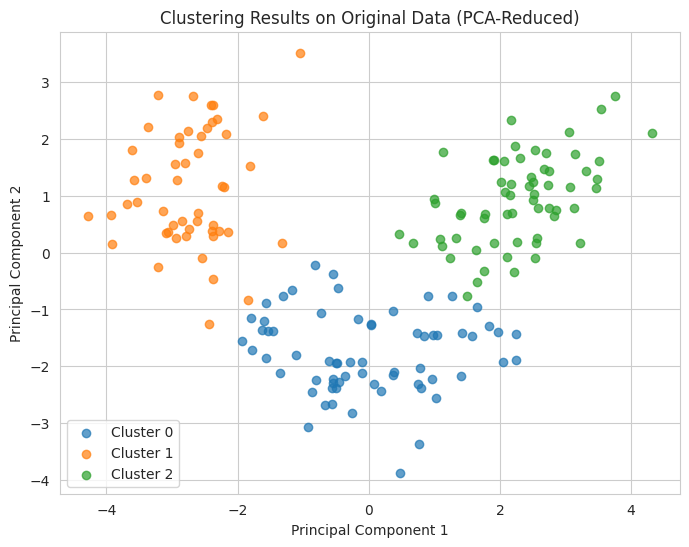

In [ ]:
import matplotlib.colors as mcolors

# Reduce to 2 principal components for visualization
pca_2d = PCA(n_components=2)
df_2d = pca_2d.fit_transform(df_scaled)

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
colors = list(mcolors.TABLEAU_COLORS.values())
for cluster in range(optimal_k):
    plt.scatter(df_2d[df["Cluster_Original"] == cluster, 0],
                df_2d[df["Cluster_Original"] == cluster, 1],
                label=f"Cluster {cluster}", alpha=0.7, color=colors[cluster])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering Results on Original Data (PCA-Reduced)")
plt.legend()
plt.show()


**Clustering on Original Data - Step 3: Visualization**

* The clusters are somewhat separable in the PCA-reduced 2D space.
* There may be some overlap, suggesting possible improvements with PCA.

**Task 4 - Clustering on PCA-Transformed Data**

In [ ]:
# Apply K-Means on PCA-transformed data
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca["Cluster_PCA"] = kmeans_pca.fit_predict(df_pca)

# Compute clustering performance metrics
silhouette_pca = silhouette_score(df_pca.iloc[:, :-1], df_pca["Cluster_PCA"])
davies_bouldin_pca = davies_bouldin_score(df_pca.iloc[:, :-1], df_pca["Cluster_PCA"])

silhouette_pca, davies_bouldin_pca


(0.29867482943692886, 1.3363263335155773)

Clustering on PCA Data - Step 1: Results
* Silhouette Score:0.30 (slightly better than original data's 0.28).
* Davies-Bouldin Index:1.34 (improved from original 1.39, indicating better clustering).


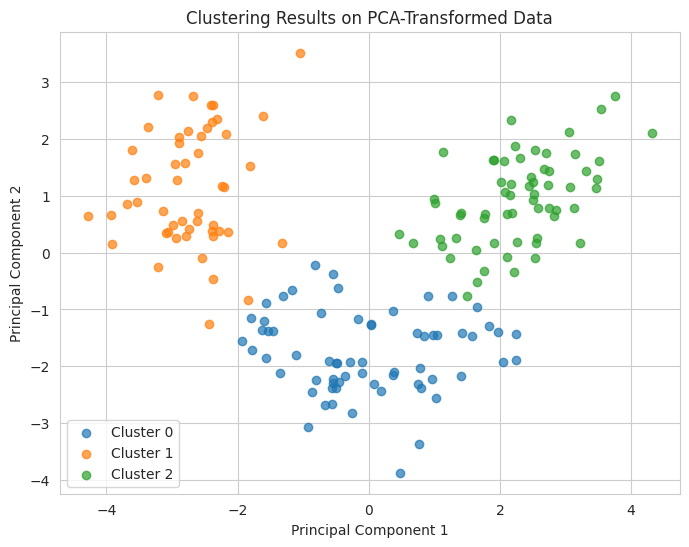

In [ ]:
# Scatter plot of clusters in PCA-transformed data
plt.figure(figsize=(8, 6))
for cluster in range(optimal_k):
    plt.scatter(df_pca[df_pca["Cluster_PCA"] == cluster]["PC1"],
                df_pca[df_pca["Cluster_PCA"] == cluster]["PC2"],
                label=f"Cluster {cluster}", alpha=0.7, color=colors[cluster])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering Results on PCA-Transformed Data")
plt.legend()
plt.show()


**Task 1: Exploratory Data Analysis (EDA)**

1. Basic Exploration:
* The dataset contains 178 rows and 14 columns.
* No missing values were found.
* All features are numerical.
2. Feature Distribution:
* Histograms showed that some features (e.g., Proline, Alcohol, Color) are right-skewed.
* Box plots revealed outliers in features like Proline, Color, and Malic.
3. Correlation Analysis:
* Strong positive correlations between Flavanoids & Phenols (0.86) and Dilution & Hue (0.79).
* Strong negative correlation between Flavanoids & Nonflavanoids (-0.72).


**Task 2: Dimensionality Reduction with PCA**

Standardization: All features were scaled to have a mean of 0 and a standard deviation of 1.
Optimal Number of Components:
A scree plot indicated that 10 principal components explain 95% of the variance.
Transformation: The dataset was transformed into these 10 principal components.
Task 3: Clustering on Original Data
Optimal Number of Clusters:
Using the Elbow Method and Silhouette Score, 3 clusters were chosen.
K-Means Clustering:
Applied on the original dataset.
Silhouette Score: 0.28.
Davies-Bouldin Index: 1.39.
Visualization:
A PCA-reduced 2D scatter plot was generated to display the clusters.
Task 4: Clustering on PCA-Transformed Data
K-Means Clustering on PCA Data:
Used the same 3 clusters.
Silhouette Score improved to 0.30.
Davies-Bouldin Index improved to 1.34 (better clustering).
Visualization (Pending):
